# Multi-Step Addition Judge Analysis

This notebook aggregates the JSON reports emitted by `multi_step_addition_experiment.py` and summarizes judge accuracy as a function of the number of consecutive addition steps.

In [2]:
import json
import math
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path("multi_addition_runs")
assert DATA_DIR.exists(), f"Directory {DATA_DIR} not found."
REPORT_FILES = sorted(DATA_DIR.glob("*.json"))
REPORT_FILES

[PosixPath('multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-0.6B_seed21.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-0.6B_seed37.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-1.7B_seed13.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-1.7B_seed21.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-1.7B_seed37.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-4B_seed13.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-4B_seed21.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-4B_seed37.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-8B_seed13.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-8B_seed21.json'),
 PosixPath('multi_addition_runs/Qwen_Qwen3-8B_seed37.json'),
 PosixPath('multi_addition_runs/meta-llama_Llama-3.1-8B-Instruct_seed13.json'),
 PosixPath('multi_addition_runs/meta-llama_Llama-3.1-8B-Instruct_seed21.json'),
 PosixPath('multi_addition_runs/meta-llama_Llama-3.1-8B-Instruct_seed37.json'),
 PosixPath('mult

In [3]:
records = []
for path in REPORT_FILES:
    with path.open() as f:
        payload = json.load(f)
    model_name = path.stem.split("_seed")[0].replace("_", "/", 1)
    seed_str = path.stem.split("_seed")[-1]
    seed = int(seed_str) if seed_str.isdigit() else math.nan
    for split in payload["splits"]:
        step_label = split["name"]
        records.append(
            {
                "model": model_name,
                "seed": seed,
                "step_label": step_label,
                "steps": int(step_label.split("=")[-1]),
                "accuracy": split["accuracy"],
                "std": split["std"],
                "examples": split["num_examples"],
                "unresolved": split["num_unresolved"],
                "report_path": path.as_posix(),
            }
        )

df = pd.DataFrame(records)
df.sort_values(["model", "seed", "steps"], inplace=True)
df.head()

,model,seed,step_label,steps,accuracy,std,examples,unresolved,report_path
0,Qwen/Qwen3-0.6B,13,steps=1,1,0.510,0.500150,1000,0,multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json
1,Qwen/Qwen3-0.6B,13,steps=2,2,0.500,0.500250,1000,0,multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json
2,Qwen/Qwen3-0.6B,13,steps=3,3,0.510,0.500150,1000,0,multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json
3,Qwen/Qwen3-0.6B,13,steps=4,4,0.501,0.500249,1000,0,multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json
4,Qwen/Qwen3-0.6B,13,steps=5,5,0.644,0.479055,1000,0,multi_addition_runs/Qwen_Qwen3-0.6B_seed13.json


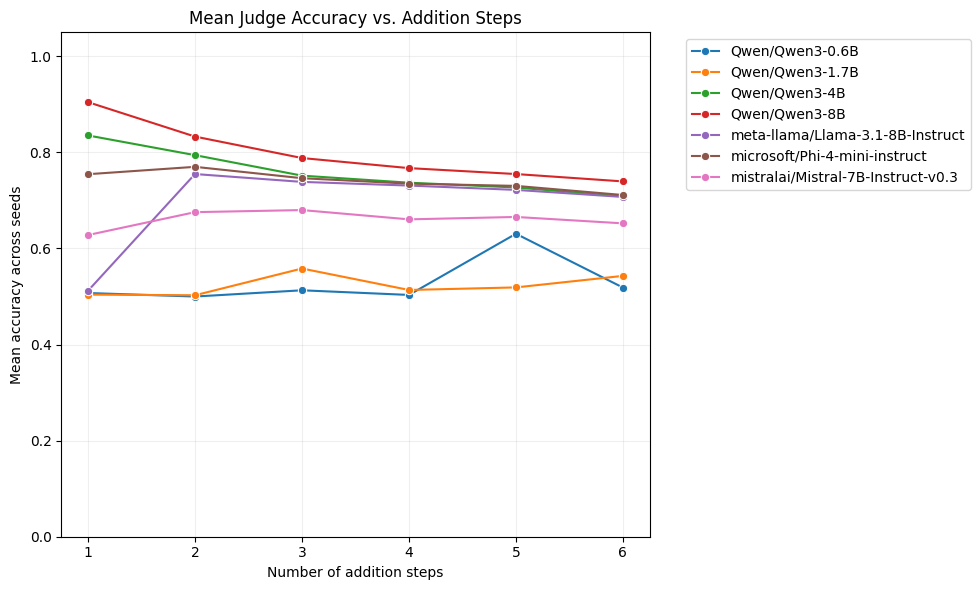

In [4]:
agg = (
    df.groupby(['model', 'steps'])['accuracy']
      .mean()
      .reset_index()
)
plt.figure(figsize=(10, 6))
sns.lineplot(data=agg, x='steps', y='accuracy', hue='model', marker='o')
plt.title('Mean Judge Accuracy vs. Addition Steps')
plt.ylabel('Mean accuracy across seeds')
plt.xlabel('Number of addition steps')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


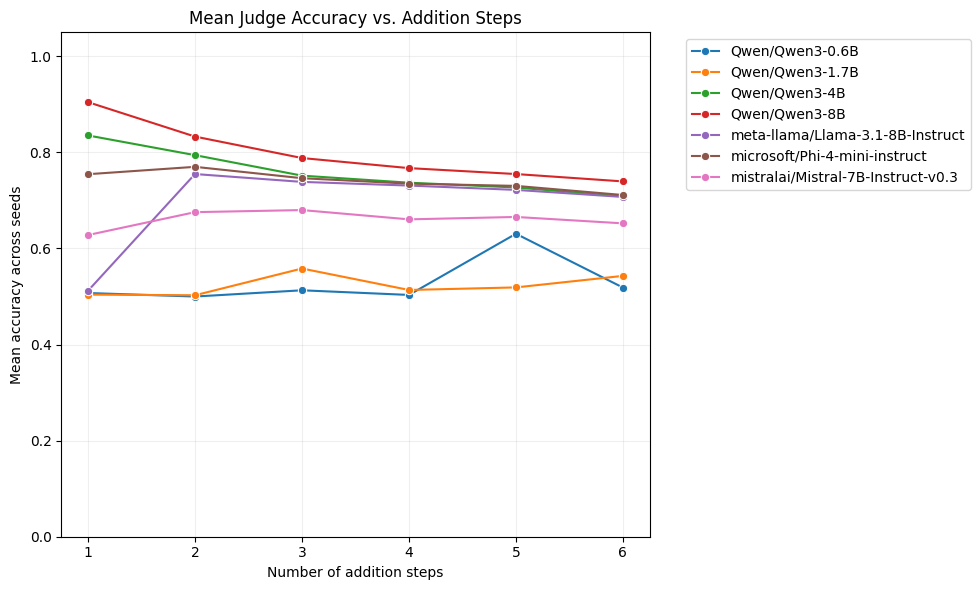

In [5]:
agg = (
    df.groupby(["model", "steps"])["accuracy"]
      .mean()
      .reset_index()
)
plt.figure(figsize=(10, 6))
sns.lineplot(data=agg, x="steps", y="accuracy", hue="model", marker="o")
plt.title("Mean Judge Accuracy vs. Addition Steps")
plt.ylabel("Mean accuracy across seeds")
plt.xlabel("Number of addition steps")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
